# Detecting Twenty-thousand Classes using Image-level Supervision

<img align="center" src="https://github.com/facebookresearch/Detic/raw/main/docs/teaser.jpeg" width="800">

This is a colab demo of using Detic (A **Det**ector with **i**mage **c**lasses). We will use the pretrained Detic models to run object detection on both the detector's vocabulary and any user-specifid vocabulary.

This demo is modified from the [detectron2 colab tutorial](https://colab.research.google.com/drive/16jcaJoc6bCFAQ96jDe2HwtXj7BMD_-m5).

You can make a copy of this tutorial by "File -> Open in playground mode" and make changes there. __DO NOT__ request access to this tutorial.


In [1]:
# Install detectron2
import torch
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
# Install detectron2 that matches the above pytorch version
# See https://detectron2.readthedocs.io/tutorials/install.html for instructions
# !pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/$CUDA_VERSION/torch$TORCH_VERSION/index.html
!git clone https://github.com/facebookresearch/detectron2.git
!python -m pip install -e detectron2
# Use the below line to install detectron2 if the above one has an error
# !python -m pip install 'git+https://github.com/facebookresearch/detectron2.git@v0.6'

torch:  2.0 ; cuda:  cu117
fatal: 目标路径 'detectron2' 已经存在，并且不是一个空目录。
Obtaining file:///home/fdse/zzy/craft/detectron2
  Preparing metadata (setup.py) ... done
  Attempting uninstall: detectron2
    Found existing installation: detectron2 0.6
    Uninstalling detectron2-0.6:
      Successfully uninstalled detectron2-0.6
  Running setup.py develop for detectron2


In [2]:
# clone and install Detic
!git clone https://github.com/facebookresearch/Detic.git --recurse-submodules
%cd Detic
!pip install -r requirements.txt

fatal: 目标路径 'Detic' 已经存在，并且不是一个空目录。
/home/fdse/zzy/craft/Detic
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-k5a4mg5k
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-k5a4mg5k
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


In [4]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import sys
import numpy as np
import os, json, cv2, random

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

# Detic libraries
sys.path.insert(0, 'third_party/CenterNet2/')
from centernet.config import add_centernet_config
from detic.config import add_detic_config
from detic.modeling.utils import reset_cls_test

/home/fdse/anaconda3/envs/reflect_env/lib/python3.9/site-packages/torch/cuda/__init__.py:107: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
/home/fdse/anaconda3/envs/reflect_env/lib/python3.9/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/fdse/anaconda3/envs/reflect_env/lib/python3.9/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please

In [6]:
# Build the detector and download our pretrained weights
cfg = get_cfg()
add_centernet_config(cfg)
add_detic_config(cfg)
cfg.merge_from_file("configs/Detic_LCOCOI21k_CLIP_SwinB_896b32_4x_ft4x_max-size.yaml")
cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/detic/Detic_LCOCOI21k_CLIP_SwinB_896b32_4x_ft4x_max-size.pth'
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
cfg.MODEL.ROI_BOX_HEAD.ZEROSHOT_WEIGHT_PATH = 'rand'
cfg.MODEL.ROI_HEADS.ONE_CLASS_PER_PROPOSAL = True # For better visualization purpose. Set to False for all classes.
# Try to use CUDA, fallback to CPU if there's an error
try:
    predictor = DefaultPredictor(cfg)
except RuntimeError as e:
    if 'cuda' in str(e).lower() or 'CUDA' in str(e):
        print(f"CUDA error detected: {e}")
        print("Falling back to CPU mode...")
        cfg.MODEL.DEVICE = 'cpu'
        predictor = DefaultPredictor(cfg)
    else:
        raise

CUDA error detected: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW
Falling back to CPU mode...
[12/31 04:26:38 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detic/Detic_LCOCOI21k_CLIP_SwinB_896b32_4x_ft4x_max-size.pth ...


Detic_LCOCOI21k_CLIP_SwinB_896b32_4x_ft4x_max-size.pth: 702MB [00:32, 21.3MB/s]                               


In [7]:
# Setup the model's vocabulary using build-in datasets

BUILDIN_CLASSIFIER = {
    'lvis': 'datasets/metadata/lvis_v1_clip_a+cname.npy',
    'objects365': 'datasets/metadata/o365_clip_a+cnamefix.npy',
    'openimages': 'datasets/metadata/oid_clip_a+cname.npy',
    'coco': 'datasets/metadata/coco_clip_a+cname.npy',
}

BUILDIN_METADATA_PATH = {
    'lvis': 'lvis_v1_val',
    'objects365': 'objects365_v2_val',
    'openimages': 'oid_val_expanded',
    'coco': 'coco_2017_val',
}

vocabulary = 'lvis' # change to 'lvis', 'objects365', 'openimages', or 'coco'
metadata = MetadataCatalog.get(BUILDIN_METADATA_PATH[vocabulary])
classifier = BUILDIN_CLASSIFIER[vocabulary]
num_classes = len(metadata.thing_classes)
reset_cls_test(predictor.model, classifier, num_classes)

Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy


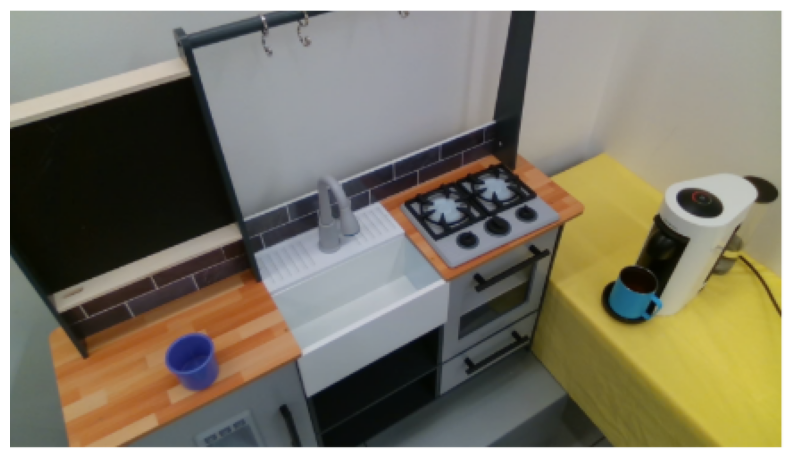

In [9]:
# Download a sample image and display. Replace path here to try your own images!
# !wget https://web.eecs.umich.edu/~fouhey/fun/desk/desk.jpg
import matplotlib.pyplot as plt
import numpy as np

im = cv2.imread("../tesk.png")
# Display image using matplotlib (for local Jupyter, not Colab)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

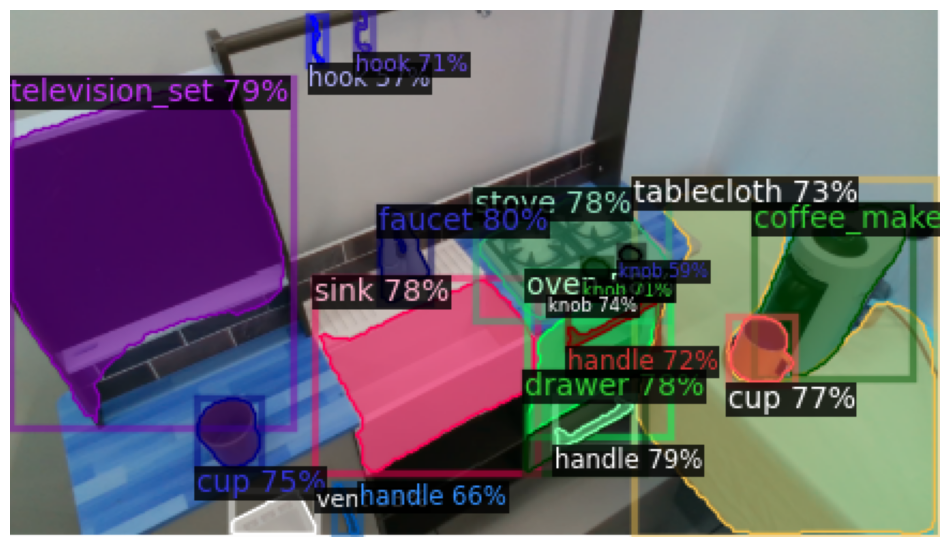

In [10]:
# Run model and show results
outputs = predictor(im)
v = Visualizer(im[:, :, ::-1], metadata)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
# Display results using matplotlib (for local Jupyter, not Colab)
result_image = out.get_image()[:, :, ::-1]
plt.figure(figsize=(12, 10))
plt.imshow(result_image)
plt.axis('off')
plt.show()

In [11]:
# Change the model's vocabulary to a customized one and get their word-embedding
#  using a pre-trained CLIP model.

from detic.modeling.text.text_encoder import build_text_encoder
def get_clip_embeddings(vocabulary, prompt='a '):
    text_encoder = build_text_encoder(pretrain=True)
    text_encoder.eval()
    texts = [prompt + x for x in vocabulary]
    emb = text_encoder(texts).detach().permute(1, 0).contiguous().cpu()
    return emb

vocabulary = 'custom'
# Use a unique name for the custom metadata catalog to avoid AssertionError
# if thing_classes has been set before for '__unused'.
metadata = MetadataCatalog.get(f"custom_vocabulary_metadata_{len(MetadataCatalog.keys())}")
metadata.thing_classes = ['coffee maker', 'purple cup', 'blue cup with handle', 'sink'] # Change here to try your own vocabularies!
classifier = get_clip_embeddings(metadata.thing_classes)
num_classes = len(metadata.thing_classes)
reset_cls_test(predictor.model, classifier, num_classes)
# Reset visualization threshold
output_score_threshold = 0.3
for cascade_stages in range(len(predictor.model.roi_heads.box_predictor)):
    predictor.model.roi_heads.box_predictor[cascade_stages].test_score_thresh = output_score_threshold

Loading pretrained CLIP


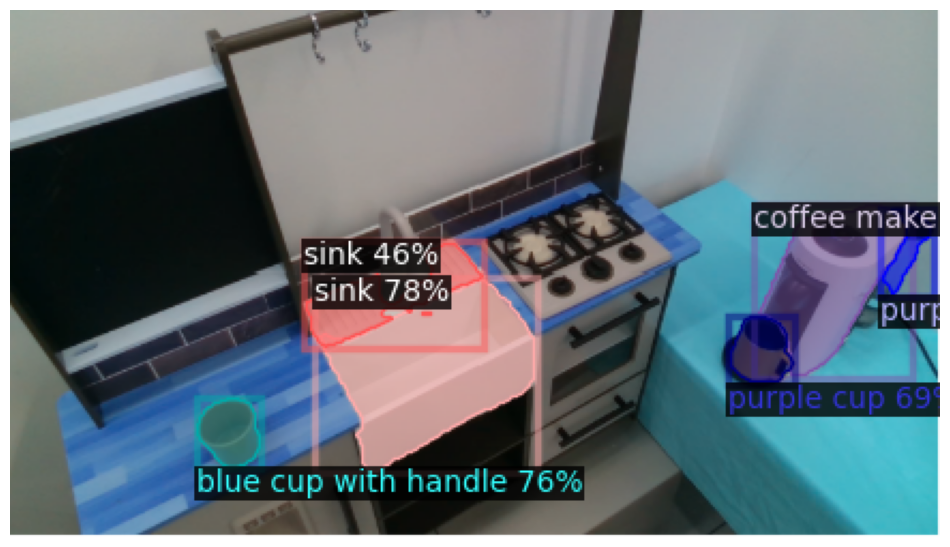

In [12]:
# Run model and show results
outputs = predictor(im)
v = Visualizer(im[:, :, ::-1], metadata)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
# Display results using matplotlib (for local Jupyter, not Colab)
result_image = out.get_image()[:, :, ::-1]
plt.figure(figsize=(12, 10))
plt.imshow(result_image)
plt.axis('off')
plt.show()

In [13]:
# look at the outputs.
# See https://detectron2.readthedocs.io/tutorials/models.html#model-output-format for specification
print(outputs["instances"].pred_classes) # class index
print([metadata.thing_classes[x] for x in outputs["instances"].pred_classes.cpu().tolist()]) # class names
print(outputs["instances"].scores)
print(outputs["instances"].pred_boxes)

tensor([3, 2, 1, 1, 3, 0])
['sink', 'blue cup with handle', 'purple cup', 'purple cup', 'sink', 'coffee maker']
tensor([0.7842, 0.7591, 0.6868, 0.5575, 0.4551, 0.4452])
Boxes(tensor([[141.9234, 124.9058, 245.6650, 216.4782],
        [ 86.7739, 180.7368, 117.0329, 213.8715],
        [334.5630, 142.7237, 365.7603, 174.9721],
        [406.2775,  92.9183, 430.5240, 134.0436],
        [137.1845, 107.5594, 221.0952, 157.7998],
        [346.6358,  90.9824, 421.3546, 171.6678]]))
